In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from dolfin import Function, plot
def gr1(V, sol, levels=20, fs=(6.5,4)):
    u = Function(V); u.vector()[:] = sol
    plt.figure(figsize=fs)
    p = plot(u); plot(u, mode='contour', levels=levels, colors='k', linewidths=0.3)
    cax = make_axes_locatable(plt.gca()).append_axes('right', size="3%", pad=0.2)
    plt.colorbar(p, cax=cax); plt.tight_layout(); plt.show()

In [2]:
def gr2(x, y):
    plt.figure(figsize=(6,3))
    plt.plot(x, y, lw=2)
    plt.grid(alpha=0.3); plt.xlabel('x'); plt.ylabel('y')
    plt.tight_layout(); plt.show()

In [ ]:
from dolfin import * ; import numpy as np
set_log_level(LogLevel.WARNING)
N = 100
T = 0.1; M = 100; tau = T/M

def boundary(x):
    return x[0] < DOLFIN_EPS or x[0] > 1.0 - DOLFIN_EPS or \
        x[1] < DOLFIN_EPS or x[1] > 1.0 - DOLFIN_EPS

mesh = UnitSquareMesh(N, N)
V = FunctionSpace(mesh, "Lagrange", 1)
#
bc = DirichletBC(V, Constant(0.0), boundary)
u0 = interpolate(Expression("sin(pi*x[0])*sin(pi*x[1])", pi=np.pi, degree=2), V)
f  = Expression("sin(pi*x[0])*sin(pi*x[1])", pi=np.pi, degree=2)

u = TrialFunction(V); v = TestFunction(V)

a = (1/tau)*inner(u, v)*dx + inner(grad(u), grad(v))*dx
L = (1/tau)*inner(u0, v)*dx + inner(f, v)*dx

u_sol = Function(V)
solutions = []

t = 0
while t < T:
    t += tau
    eta = Expression("sin(pi*x[0])*exp(-t)", pi=np.pi, t=t, degree=2)
    bc = DirichletBC(V, eta, boundary)
    solve(a == L, u_sol, bc)
    solutions.append(u_sol.vector().get_local().copy())
    u0.assign(u_sol)

solutions = np.array(solutions)
print(f"Прямая задача: {len(solutions)} шагов, max|u| = {np.max(np.abs(solutions)):.4f}")


Прямая задача: 100 шагов, max|u| = 0.9990


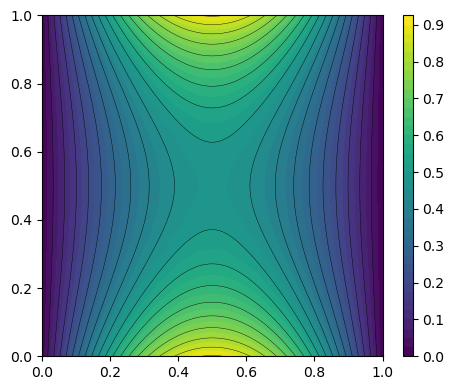

In [4]:
gr1(V, solutions[-1])

/usr/lib/petsc/lib/python3/dist-packages/dolfin/common/plotting.py:152: UserWarning: The following kwargs were not used by contour: 'axes'
  return ax.tricontourf(mesh2triang(mesh), C, levels, **kwargs)
/usr/lib/petsc/lib/python3/dist-packages/dolfin/common/plotting.py:152: UserWarning: The following kwargs were not used by contour: 'axes'
  return ax.tricontourf(mesh2triang(mesh), C, levels, **kwargs)


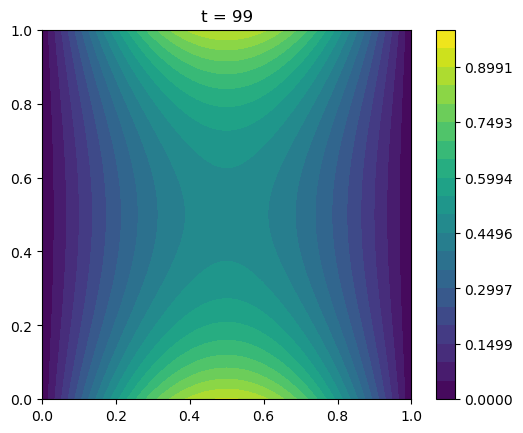

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from dolfin import *
from matplotlib.animation import FuncAnimation, PillowWriter

def gr1_gif(V, sol_list, filename="solution.gif", fps=20):
    u = Function(V)

    # Фиксируем шкалу и уровни один раз
    all_vals = np.concatenate(sol_list)
    vmin, vmax = float(all_vals.min()), float(all_vals.max())
    levels = np.linspace(vmin, vmax, 21)

    fig, ax = plt.subplots()

    # Первый кадр — создаём colorbar ДО анимации
    u.vector()[:] = sol_list[0]
    p0 = plot(u, mode='contourf', levels=levels, axes=ax)
    cbar = fig.colorbar(p0, ax=ax)

    def update(i):
        ax.cla()                          # очищаем только оси, colorbar не трогаем
        u.vector()[:] = sol_list[i]
        plot(u, mode='contourf', levels=levels, axes=ax)
        ax.set_title(f"t = {i}")          # опционально

    ani = FuncAnimation(fig, update, frames=len(sol_list), blit=False)
    ani.save(filename, writer=PillowWriter(fps=fps))
    plt.show()

gr1_gif(V, solutions)

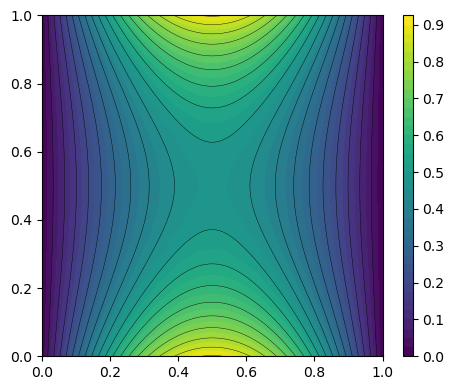

In [16]:
phi = solutions[-1]
gr1(V, phi)
# 1. Зашумление φ(t)
# delta = 0.01
# np.random.seed(42)
# noise = (delta * np.exp(-(10000*(t-T/2)**2 ) ) * np.random.randn(M))
# phi_t_noisy = phi.copy() + noise

# # 2. Сглаживание фильтром Савицкого-Голея
# from scipy.signal import savgol_filter
# phi_t_filtered = savgol_filter(phi_t_noisy, window_length=25, polyorder=5)

# # 3. Визуализация
# plt.figure(figsize=(8, 4))
# tt = np.linspace(tau, T, M)
# plt.plot(tt, phi_t,          "k--", lw=1.5, label="точное φ(t)")
# plt.plot(tt, phi_t_noisy,    "r-",  lw=1,   alpha=0.5, label=f"зашумлённое (δ={delta})")
# plt.plot(tt, phi_t_filtered, "b-",  lw=2,   label="после СГ (w=11, p=3)")
# plt.legend(); plt.grid(alpha=0.3); plt.xlabel("t"); plt.ylabel("φ(t)")
# plt.tight_layout(); plt.show()

# # Подаём в алгоритм отфильтрованное
# phi_t = phi_t_filtered


In [20]:
coords = V.tabulate_dof_coordinates().reshape((-1, 2))
idx = np.lexsort((coords[:,0], coords[:,1]))
coords_sorted = coords[idx]
values_sorted = phi[idx]

# reshape
phi_grid = values_sorted.reshape((N+1, N+1))

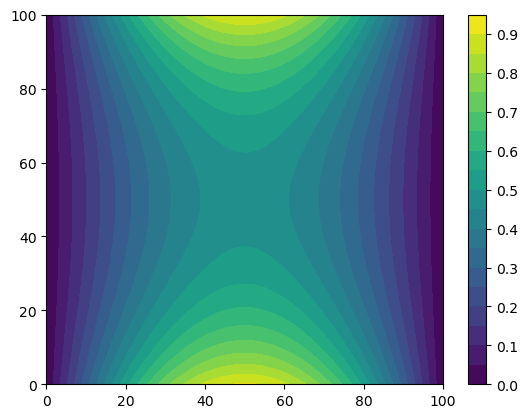

In [21]:
p = plt.contourf(phi_grid, levels=20)
plt.colorbar(p)
plt.show()

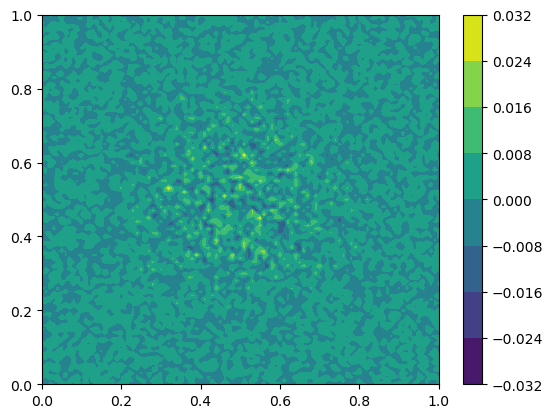

In [ ]:
L = 1.0
x = np.linspace(0, L, N+1)
y = np.linspace(0, L, N+1)
xx, yy = np.meshgrid(x, y)
delta = 0.01
noise = (delta * np.exp(-(10*((xx - L/2)**2 + (yy - L/2)**2) )) * np.random.randn(N+1, N+1)) 
p = plt.contourf(xx, yy, noise)

phi_noise = phi_grid + noise

plt.colorbar(p)
plt.show()

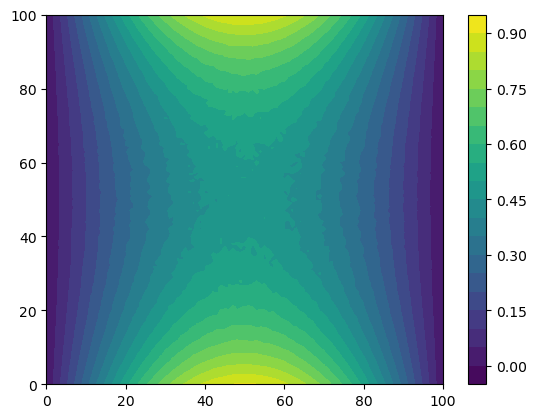

In [23]:
p = plt.contourf(phi_noise, levels=20)
plt.colorbar(p)
plt.show()

In [48]:
f  = Expression("sin(pi*x[0])*sin(pi*x[1])", pi=np.pi, degree=2)


values_sorted = phi_noise.reshape(-1)
values = np.zeros_like(values_sorted)
values[idx] = values_sorted
phi_ = Function(V)
phi_.vector()[:] = values


u = TrialFunction(V); v = TestFunction(V)
uT = Function(V)
uT.assign(phi_)
a = (1/tau)*inner(u, v)*dx + inner(grad(u), grad(v))*dx


m = "cg"
p = "ilu"

u_sol = Function(V)

solver = KrylovSolver(m, p)
prm = solver.parameters
prm["absolute_tolerance"] = 1E-7; prm["relative_tolerance"] = 1E-4; prm["maximum_iterations"] = 100000
sol_r = []
t = T
eta = Expression("sin(pi*x[0])*exp(-t)", pi=np.pi, t=t, degree=2)
eta.t = T
A = assemble(a)
while 0 < t:
    eta.t = t
    L = (1/tau)*inner(uT, v)*dx + inner(f, v)*dx
    bc = DirichletBC(V, eta, boundary)
    U = u_sol.vector()
    b = assemble(L)
    bc.apply(A, b)
    t -= tau
    iter = solver.solve(A, U, b)
    sol_r.append(u_sol.vector().get_local().copy())
    uT.assign(u_sol)

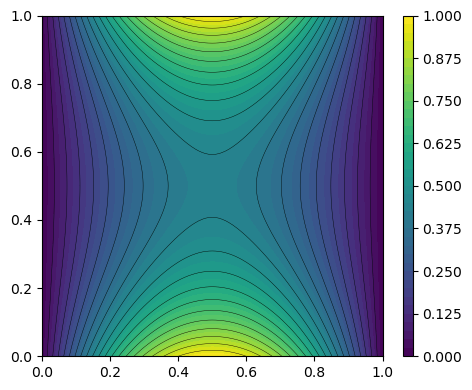

In [50]:
gr1(V, sol_r[-1])

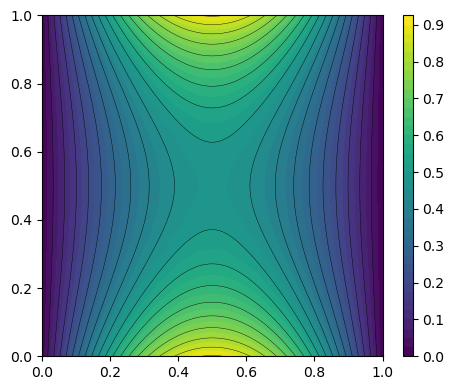

In [51]:
gr1(V, solutions[-1])